### Comparing centrolign mutation rate in the array to the flanks 

In [1]:
import os
import gzip
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict

In [3]:
# ── Configuration ─────────────────────────────────────────────────────────────

VCF_DIR  = "/private/groups/patenlab/mira/centrolign/analysis/mutation_rate_comparison_to_flanks/flanking_50kb"
BED_DIR  = "/private/groups/patenlab/mira/centrolign/analysis/mutation_rate_comparison_to_flanks/per_sample_maf_beds"
CHROMS   = [f"chr{i}" for i in list(range(1, 23)) + ["X", "Y"]]

In [47]:

# ── Helper functions ──────────────────────────────────────────────────────────

def open_vcf(path):
    return gzip.open(path, "rt") if path.endswith(".gz") else open(path)


def get_vcf_samples(vcf_path):
    with open_vcf(vcf_path) as f:
        for line in f:
            if line.startswith("#CHROM"):
                return line.strip().split("\t")[9:]
    return []


def load_bed_total_bases(bed_dir, chroms):
    """
    For each sample haplotype and chrom, sum total reference bases covered by BED blocks.
    Auto-discovers all *.bed files in bed_dir. Files must be named {sample}.bed
    where sample includes the haplotype, e.g. HG00097.1.bed -> hap_id = "HG00097.1".
    Returns dict: (hap_id, chrom) -> total_bases
    e.g. ("HG00097.1", "chr20") -> 48000
    """
    from pathlib import Path
    totals = defaultdict(int)
    chroms_set = set(chroms)
    for bed_path in Path(bed_dir).glob("*.mrg.bed"):
        hap_id = bed_path.name.replace(".mrg.bed", "")  # e.g. "HG00097.1"
        with open(bed_path) as f:
            for line in f:
                if line.startswith("#") or not line.strip():
                    continue
                fields = line.split("\t")
                chrom, start, end = fields[0], int(fields[1]), int(fields[2])
                if chrom in chroms_set:
                    totals[(hap_id, chrom)] += (end - start)
    return totals


In [48]:

# ── Main calculation ──────────────────────────────────────────────────────────

# Accumulators: sample -> chrom -> {snvs, deleted_bases, total_ref_bases}
records = defaultdict(lambda: {"snvs": 0, "indels": 0, "deleted_bases": 0, "missing": 0, "total_ref_bases": 0})

# Load BED total bases per haplotype per chrom
print("Loading BED files...")
bed_totals = load_bed_total_bases(BED_DIR, set(CHROMS))

# Populate total_ref_bases from BED
for (hap_id, chrom), bases in bed_totals.items():
    records[(hap_id, chrom)]["total_ref_bases"] += bases

# Stream VCFs
for chrom in CHROMS:
    vcf_path = os.path.join(VCF_DIR, f"{chrom}_flanking_50kb.vcf.gz")
    if not os.path.exists(vcf_path):
        print(f"  Skipping {chrom} — VCF not found")
        continue
    print(f"  Processing {chrom}...")

    chrom_sample_list = get_vcf_samples(vcf_path)  # load per-chrom

    with open_vcf(vcf_path) as f:
        for line in f:
            if line.startswith("#"):
                continue
            fields  = line.rstrip("\n").split("\t")
            ref     = fields[3]
            alts    = fields[4].split(",")
            fmt     = fields[8].split(":")
            gt_idx  = fmt.index("GT") if "GT" in fmt else 0
            ref_len = len(ref)

            for i, samp in enumerate(chrom_sample_list):
                gt_field = fields[9 + i].split(":")[gt_idx]
                alleles  = gt_field.replace("|", "/").split("/")

                for hap_idx, allele in enumerate(alleles):
                    hap_id = f"{samp}.{hap_idx + 1}"
                    key    = (hap_id, chrom)

                    if allele == ".":
                        records[key]["missing"] += 1
                        continue

                    if allele == "0":
                        # ref allele — no SNV/indel, but ref bases are aligned (no deletion)
                        continue

                    alt_seq = alts[int(allele) - 1]
                    alt_len = len(alt_seq)

                    # SNV: ref and alt are both 1 base
                    if ref_len == 1 and alt_len == 1:
                        records[key]["snvs"] += 1

                    # Short indel: < 50 bp size difference — count in numerator
                    elif abs(ref_len - alt_len) < 50:
                        records[key]["indels"] += 1

                    # All deletions (any size) reduce the denominator
                    if alt_len < ref_len:
                        records[key]["deleted_bases"] += (ref_len - alt_len)

# ── Build results dataframe ───────────────────────────────────────────────────

rows = []
for (hap_id, chrom), vals in records.items():
    total   = vals["total_ref_bases"]
    deleted = vals["deleted_bases"]
    snvs    = vals["snvs"]
    aligned = total - deleted
    rate    = snvs / aligned if aligned > 0 else np.nan
    samp    = ".".join(hap_id.split(".")[:1])
    hap     = hap_id.split(".")[1]
    rows.append({
    "sample":          samp,
    "haplotype":       hap_id,
    "chrom":           chrom,
    "total_ref_bases": total,
    "deleted_bases":   deleted,
    "aligned_bases":   aligned,
    "snvs":            snvs,
    "indels":          vals["indels"],
    "missing":         vals["missing"],
    "snv_rate":        rate,
})


df = pd.DataFrame(rows)
print(df.head(10))

Loading BED files...
  Processing chr1...
  Processing chr2...
  Processing chr3...
  Processing chr4...
  Processing chr5...
  Processing chr6...
  Processing chr7...
  Processing chr8...
  Processing chr9...
  Processing chr10...
  Processing chr11...
  Processing chr12...
  Processing chr13...
  Processing chr14...
  Processing chr15...
  Processing chr16...
  Processing chr17...
  Processing chr18...
  Processing chr19...
  Processing chr20...
  Processing chr21...
  Processing chr22...
  Processing chrX...
  Processing chrY...
    sample  haplotype  chrom  total_ref_bases  deleted_bases  aligned_bases  \
0  HG01123  HG01123.1  chr10           100000              6          99994   
1  HG01123  HG01123.1  chr11           100000             25          99975   
2  HG01123  HG01123.1  chr12            99217            519          98698   
3  HG01123  HG01123.1  chr13            99980             80          99900   
4  HG01123  HG01123.1  chr14            85867            567       

In [49]:
print(bed_totals)

defaultdict(<class 'int'>, {('HG01123.1', 'chr10'): 100000, ('HG01123.1', 'chr11'): 100000, ('HG01123.1', 'chr12'): 99217, ('HG01123.1', 'chr13'): 99980, ('HG01123.1', 'chr14'): 85867, ('HG01123.1', 'chr15'): 50000, ('HG01123.1', 'chr16'): 100000, ('HG01123.1', 'chr17'): 100000, ('HG01123.1', 'chr18'): 100000, ('HG01123.1', 'chr19'): 100000, ('HG01123.1', 'chr1'): 50000, ('HG01123.1', 'chr20'): 98513, ('HG01123.1', 'chr21'): 50000, ('HG01123.1', 'chr22'): 50000, ('HG01123.1', 'chr2'): 55482, ('HG01123.1', 'chr3'): 100000, ('HG01123.1', 'chr4'): 51256, ('HG01123.1', 'chr5'): 96753, ('HG01123.1', 'chr6'): 100000, ('HG01123.1', 'chr7'): 93456, ('HG01123.1', 'chr8'): 100000, ('HG01123.1', 'chr9'): 100000, ('HG01123.1', 'chrX'): 97282, ('NA18505.1', 'chr10'): 50000, ('NA18505.1', 'chr11'): 92166, ('NA18505.1', 'chr12'): 99815, ('NA18505.1', 'chr13'): 99955, ('NA18505.1', 'chr14'): 50000, ('NA18505.1', 'chr15'): 98536, ('NA18505.1', 'chr16'): 50000, ('NA18505.1', 'chr17'): 100000, ('NA18505.

In [50]:
# Sanity check
mask = (
    (df["total_ref_bases"] == 0) &
    (
        (df["deleted_bases"] > 0) |
        (df["snvs"] > 0) |
        (df["indels"] > 0)
    )
)
print(df[mask].to_string())


Empty DataFrame
Columns: [sample, haplotype, chrom, total_ref_bases, deleted_bases, aligned_bases, snvs, indels, missing, snv_rate]
Index: []


In [51]:
# ── Per-sample summary (collapse haplotypes and chroms) ───────────────────────

summary = (
    df.groupby("sample")
    .agg(
        total_ref_bases = ("total_ref_bases", "sum"),
        deleted_bases   = ("deleted_bases",   "sum"),
        aligned_bases   = ("aligned_bases",   "sum"),
        snvs            = ("snvs",            "sum"),
        indels          = ("indels",          "sum"),
        missing         = ("missing",         "sum"),
    )
    .reset_index()
)
summary["snv_rate"]   = summary["snvs"]   / summary["aligned_bases"]
summary["indel_rate"] = summary["indels"] / summary["aligned_bases"]
summary = summary.sort_values("snv_rate")
print(summary)


      sample  total_ref_bases  deleted_bases  aligned_bases  snvs  indels  \
181  NA18940          3698880           4792        3694088  1770     550   
95   HG02273          4048750           7731        4041019  2230     231   
27   HG00621          3912395          12878        3899517  2335     341   
177  NA18620          3916080          31892        3884188  2393     267   
187  NA18959          3787309           4808        3782501  2497     772   
..       ...              ...            ...            ...   ...     ...   
109  HG02615          4035398          23196        4012202  6321    1102   
215  NA20752          3858416          24823        3833593  6070     981   
38   HG01074          3900434          26517        3873917  6290     940   
145  HG03540          3919675          57369        3862306  6322    1708   
225  NA21093          3872217          55295        3816922  6265     984   

     missing  snv_rate  indel_rate  
181     9547  0.000479    0.000149  
9

In [52]:
df.head()

,sample,haplotype,chrom,total_ref_bases,deleted_bases,aligned_bases,snvs,indels,missing,snv_rate
0,HG01123,HG01123.1,chr10,100000,6,99994,190,16,121,0.001900
1,HG01123,HG01123.1,chr11,100000,25,99975,228,23,0,0.002281
2,HG01123,HG01123.1,chr12,99217,519,98698,198,14,41,0.002006
3,HG01123,HG01123.1,chr13,99980,80,99900,107,25,0,0.001071
4,HG01123,HG01123.1,chr14,85867,567,85300,163,73,4,0.001911


In [53]:
df[df["total_ref_bases"]>100000]

,sample,haplotype,chrom,total_ref_bases,deleted_bases,aligned_bases,snvs,indels,missing,snv_rate


In [54]:
print(df.nlargest(20, "snv_rate").to_string())


        sample  haplotype  chrom  total_ref_bases  deleted_bases  aligned_bases  snvs  indels  missing  snv_rate
4144   HG03834  HG03834.1   chr2             5483            463           5020   175     383     1216  0.034861
6031   NA18522  NA18522.1  chr21            42444           6374          36070  1102     251     2098  0.030552
1107   HG03704  HG03704.1  chr21            46932           4924          42008  1106     230     2098  0.026328
7607   NA21093  NA21093.2  chr21            46932           4640          42292  1110     229     2098  0.026246
5301   HG03804  HG03804.1  chr21            46932           4649          42283  1106     228     2098  0.026157
2244   HG00597  HG00597.2  chr21            46932           4653          42279  1104     228     2098  0.026112
9043   HG00673  HG00673.2  chr21            46932           4649          42283  1104     228     2098  0.026110
7515   NA20752  NA20752.2  chr21            46932           4653          42279  1103     228   

#### Check proportion aligned per chrom

In [55]:
df["prop_aligned"] = df["aligned_bases"] / 100_000

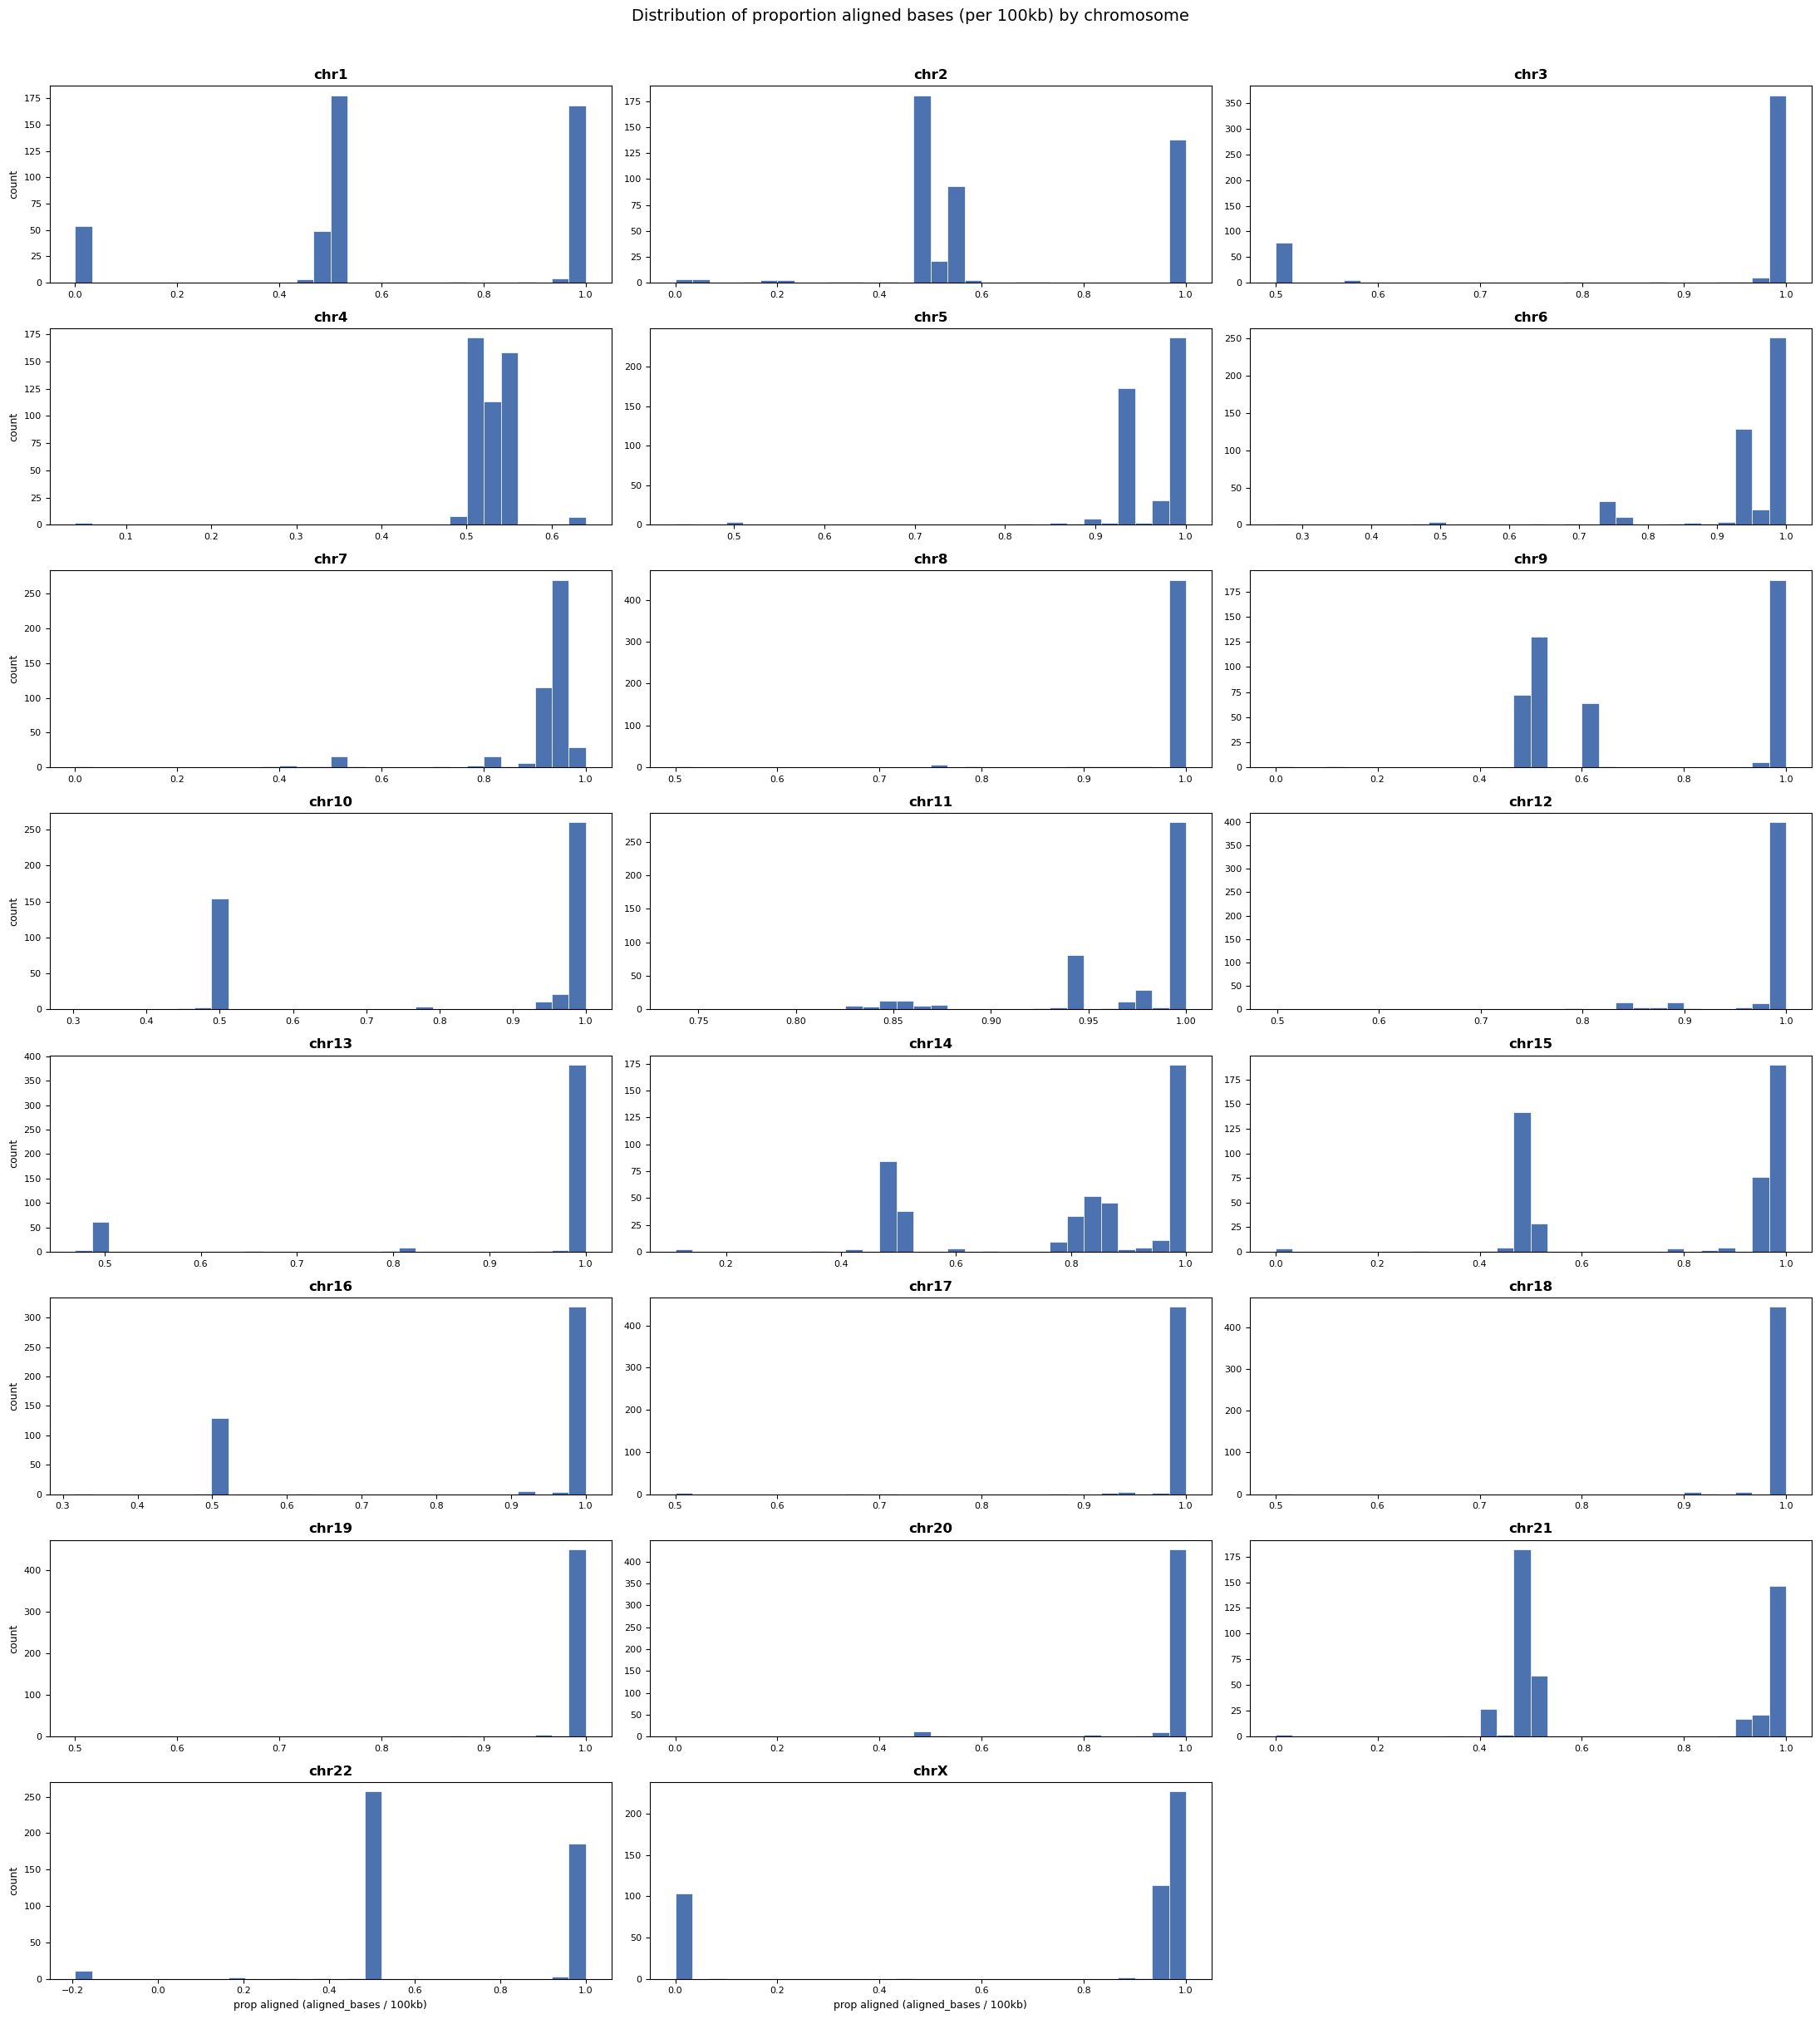

In [56]:
df["prop_aligned"] = df["aligned_bases"] / 100_000

plot_chroms = [f"chr{i}" for i in range(1, 23)] + ["chrX"]

ncols = 3
nrows = int(np.ceil(len(plot_chroms) / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(22, nrows * 3))
axes = axes.flatten()

for i, chrom in enumerate(plot_chroms):
    ax = axes[i]
    data = df[df["chrom"] == chrom]["prop_aligned"].dropna()
    ax.hist(data, bins=30, color="#4C72B0", edgecolor="white", linewidth=0.5)
    ax.set_title(chrom, fontsize=12, fontweight="bold")
    ax.set_xlabel("prop aligned (aligned_bases / 100kb)" if i >= (nrows - 1) * ncols else "", fontsize=9)
    ax.set_ylabel("count" if i % ncols == 0 else "", fontsize=9)
    ax.tick_params(labelsize=8)

for j in range(len(plot_chroms), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Distribution of proportion aligned bases (per 100kb) by chromosome", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


In [57]:
import subprocess

VCF_DIR = "/private/groups/patenlab/mira/centrolign/analysis/mutation_rate_comparison_to_flanks/flanking_50kb"
plot_chroms = [f"chr{i}" for i in range(1, 23)] + ["chrX"]

rows = []
for chrom in plot_chroms:
    vcf_path = os.path.join(VCF_DIR, f"{chrom}_flanking_50kb.vcf.gz")
    if not os.path.exists(vcf_path):
        continue
    result = subprocess.run(
        f"bcftools view -H {vcf_path} | wc -l",
        shell=True, capture_output=True, text=True
    )
    rows.append({"chrom": chrom, "n_variants": int(result.stdout.strip())})

geno_df = pd.DataFrame(rows)
print(geno_df.to_string())


    chrom  n_variants
0    chr1        1566
1    chr2        1939
2    chr3        2346
3    chr4         702
4    chr5        3556
5    chr6        3756
6    chr7        3820
7    chr8        2203
8    chr9        2345
9   chr10        3535
10  chr11        4094
11  chr12        3553
12  chr13        4382
13  chr14        3326
14  chr15        3535
15  chr16        2416
16  chr17        3006
17  chr18        2203
18  chr19        2759
19  chr20        4764
20  chr21        4945
21  chr22        2937
22   chrX        2117


In [58]:
df = df.merge(geno_df, on="chrom", how="left")
df["prop_missing"] = df["missing"] / df["n_variants"]


In [59]:
df.head()

,sample,haplotype,chrom,total_ref_bases,deleted_bases,aligned_bases,snvs,indels,missing,snv_rate,prop_aligned,n_variants,prop_missing
0,HG01123,HG01123.1,chr10,100000,6,99994,190,16,121,0.001900,0.99994,3535.0,0.034229
1,HG01123,HG01123.1,chr11,100000,25,99975,228,23,0,0.002281,0.99975,4094.0,0.000000
2,HG01123,HG01123.1,chr12,99217,519,98698,198,14,41,0.002006,0.98698,3553.0,0.011540
3,HG01123,HG01123.1,chr13,99980,80,99900,107,25,0,0.001071,0.99900,4382.0,0.000000
4,HG01123,HG01123.1,chr14,85867,567,85300,163,73,4,0.001911,0.85300,3326.0,0.001203


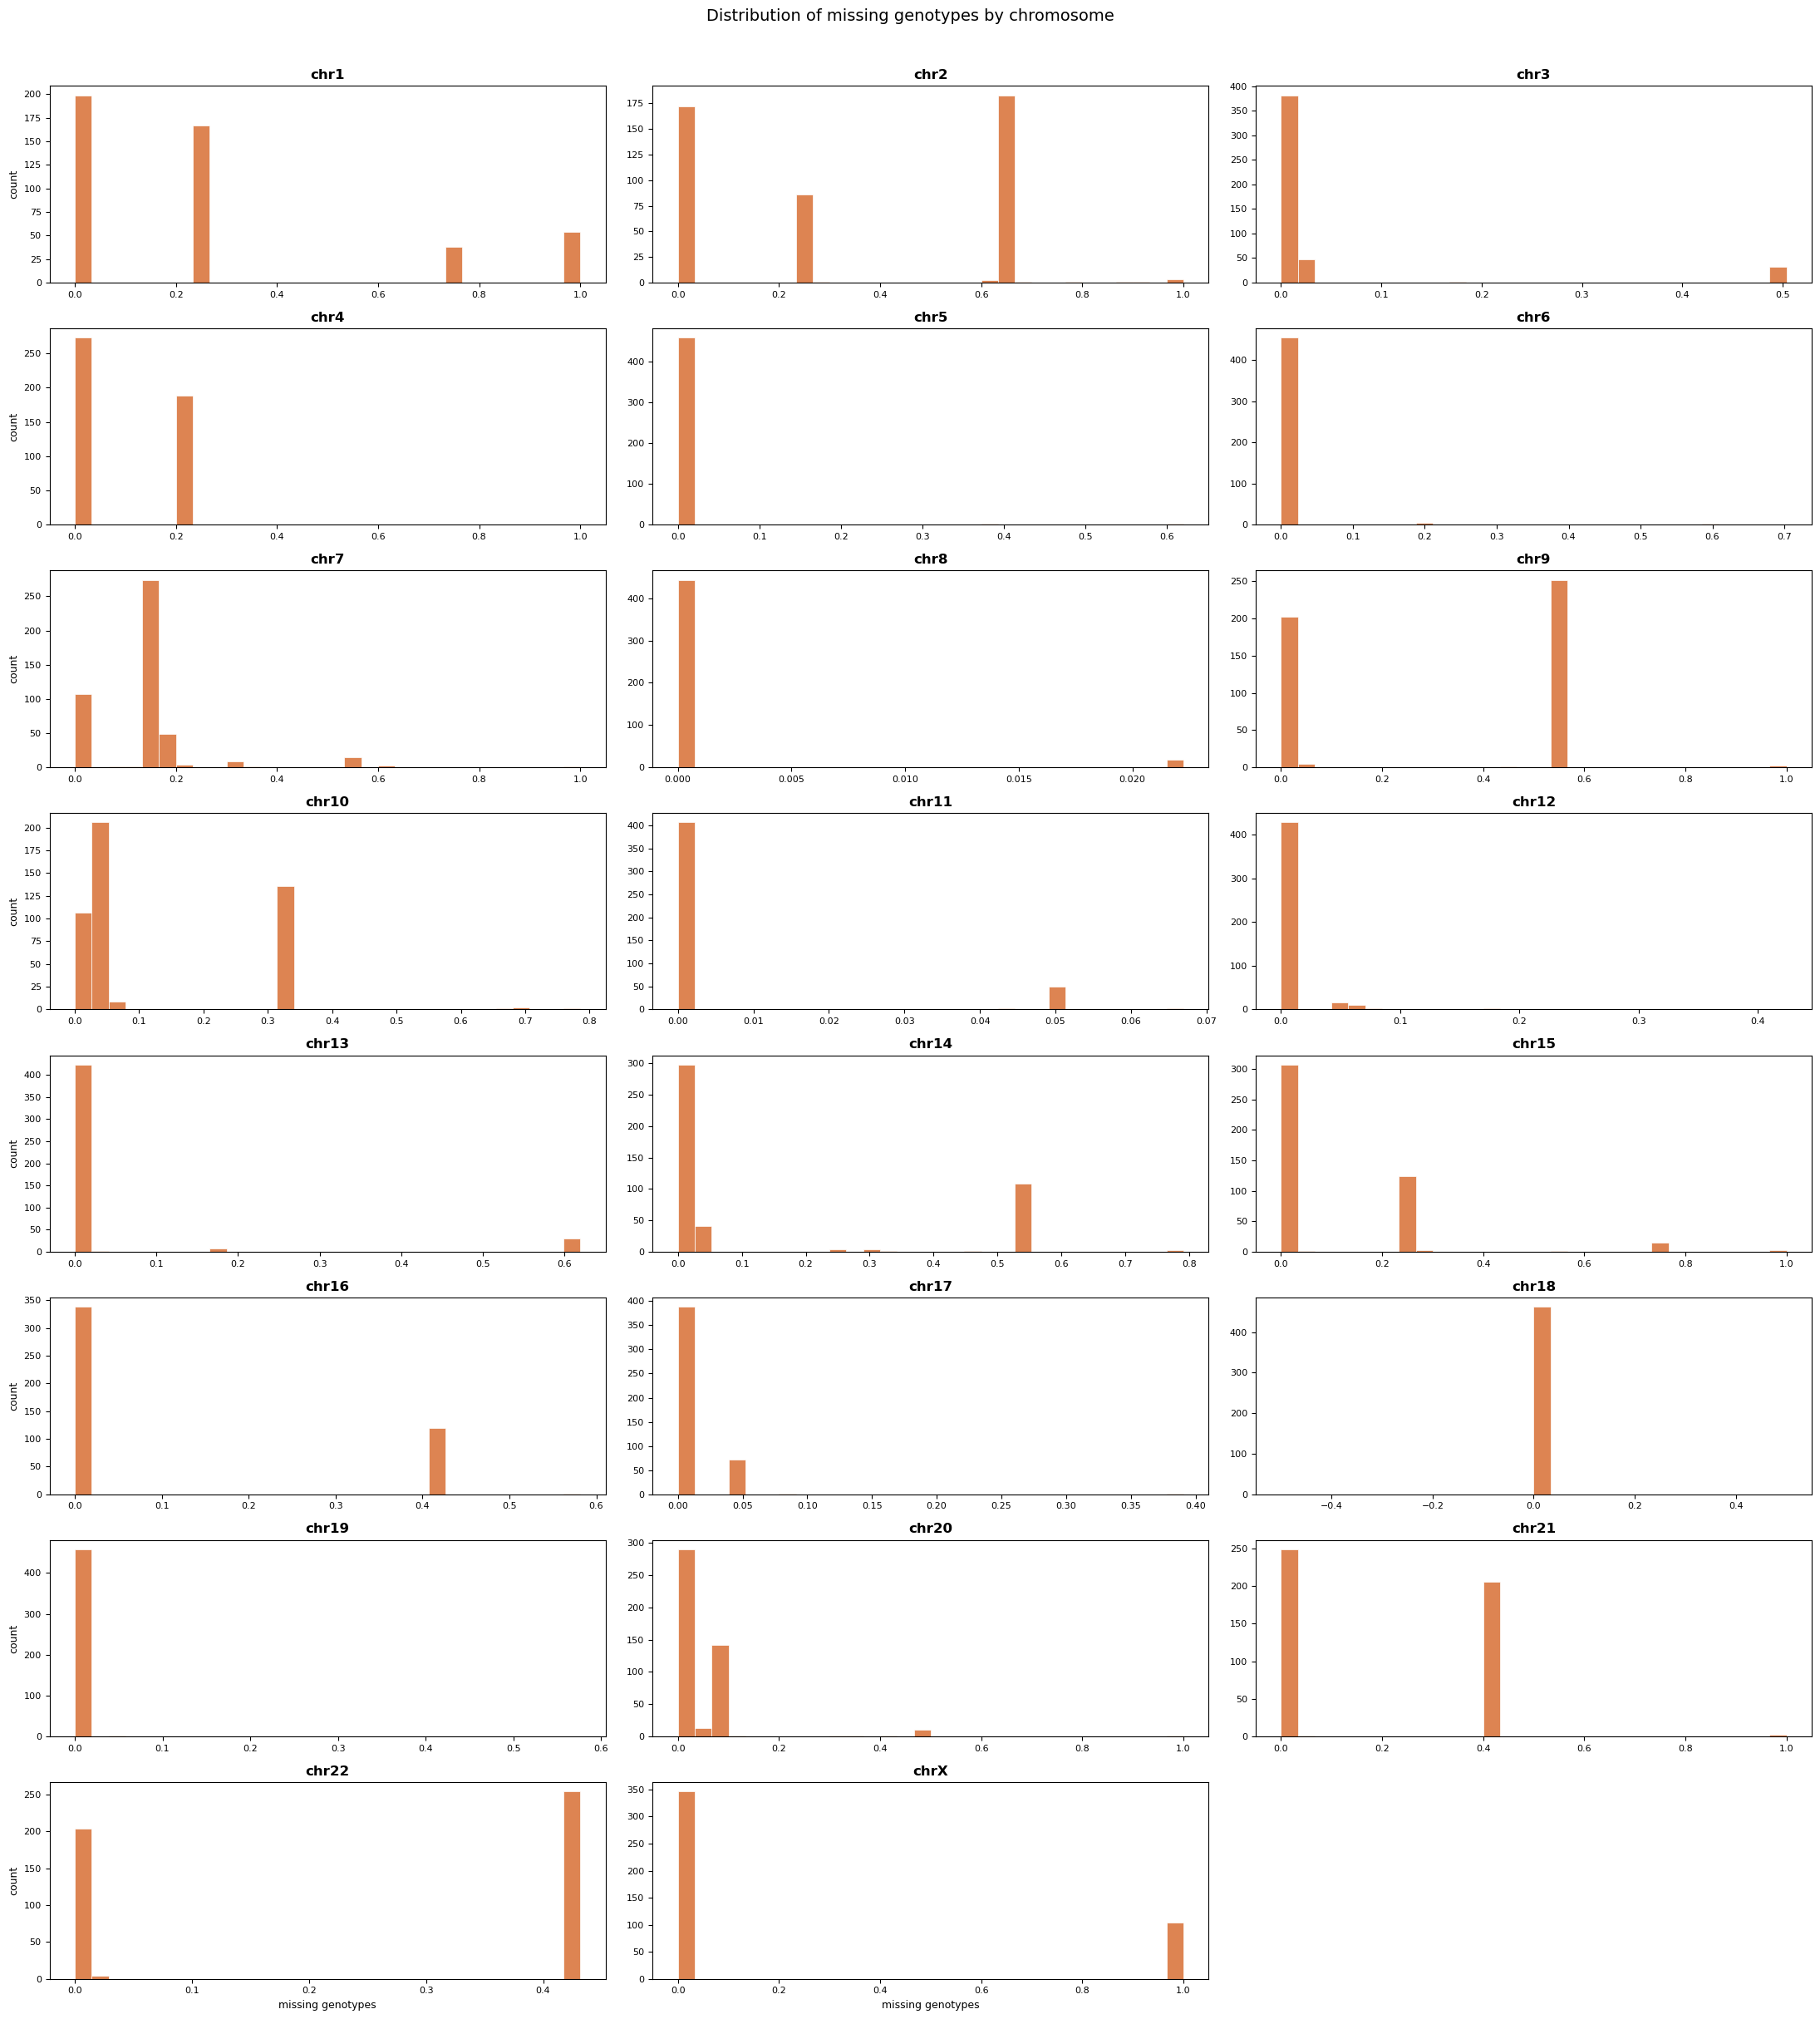

In [60]:
plot_chroms = [f"chr{i}" for i in range(1, 23)] + ["chrX"]

ncols = 3
nrows = int(np.ceil(len(plot_chroms) / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(22, nrows * 3))
axes = axes.flatten()

for i, chrom in enumerate(plot_chroms):
    ax = axes[i]
    data = df[df["chrom"] == chrom]["prop_missing"].dropna()
    ax.hist(data, bins=30, color="#DD8452", edgecolor="white", linewidth=0.5)
    ax.set_title(chrom, fontsize=12, fontweight="bold")
    ax.set_xlabel("missing genotypes" if i >= (nrows - 1) * ncols else "", fontsize=9)
    ax.set_ylabel("count" if i % ncols == 0 else "", fontsize=9)
    ax.tick_params(labelsize=8)

for j in range(len(plot_chroms), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Distribution of missing genotypes by chromosome", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

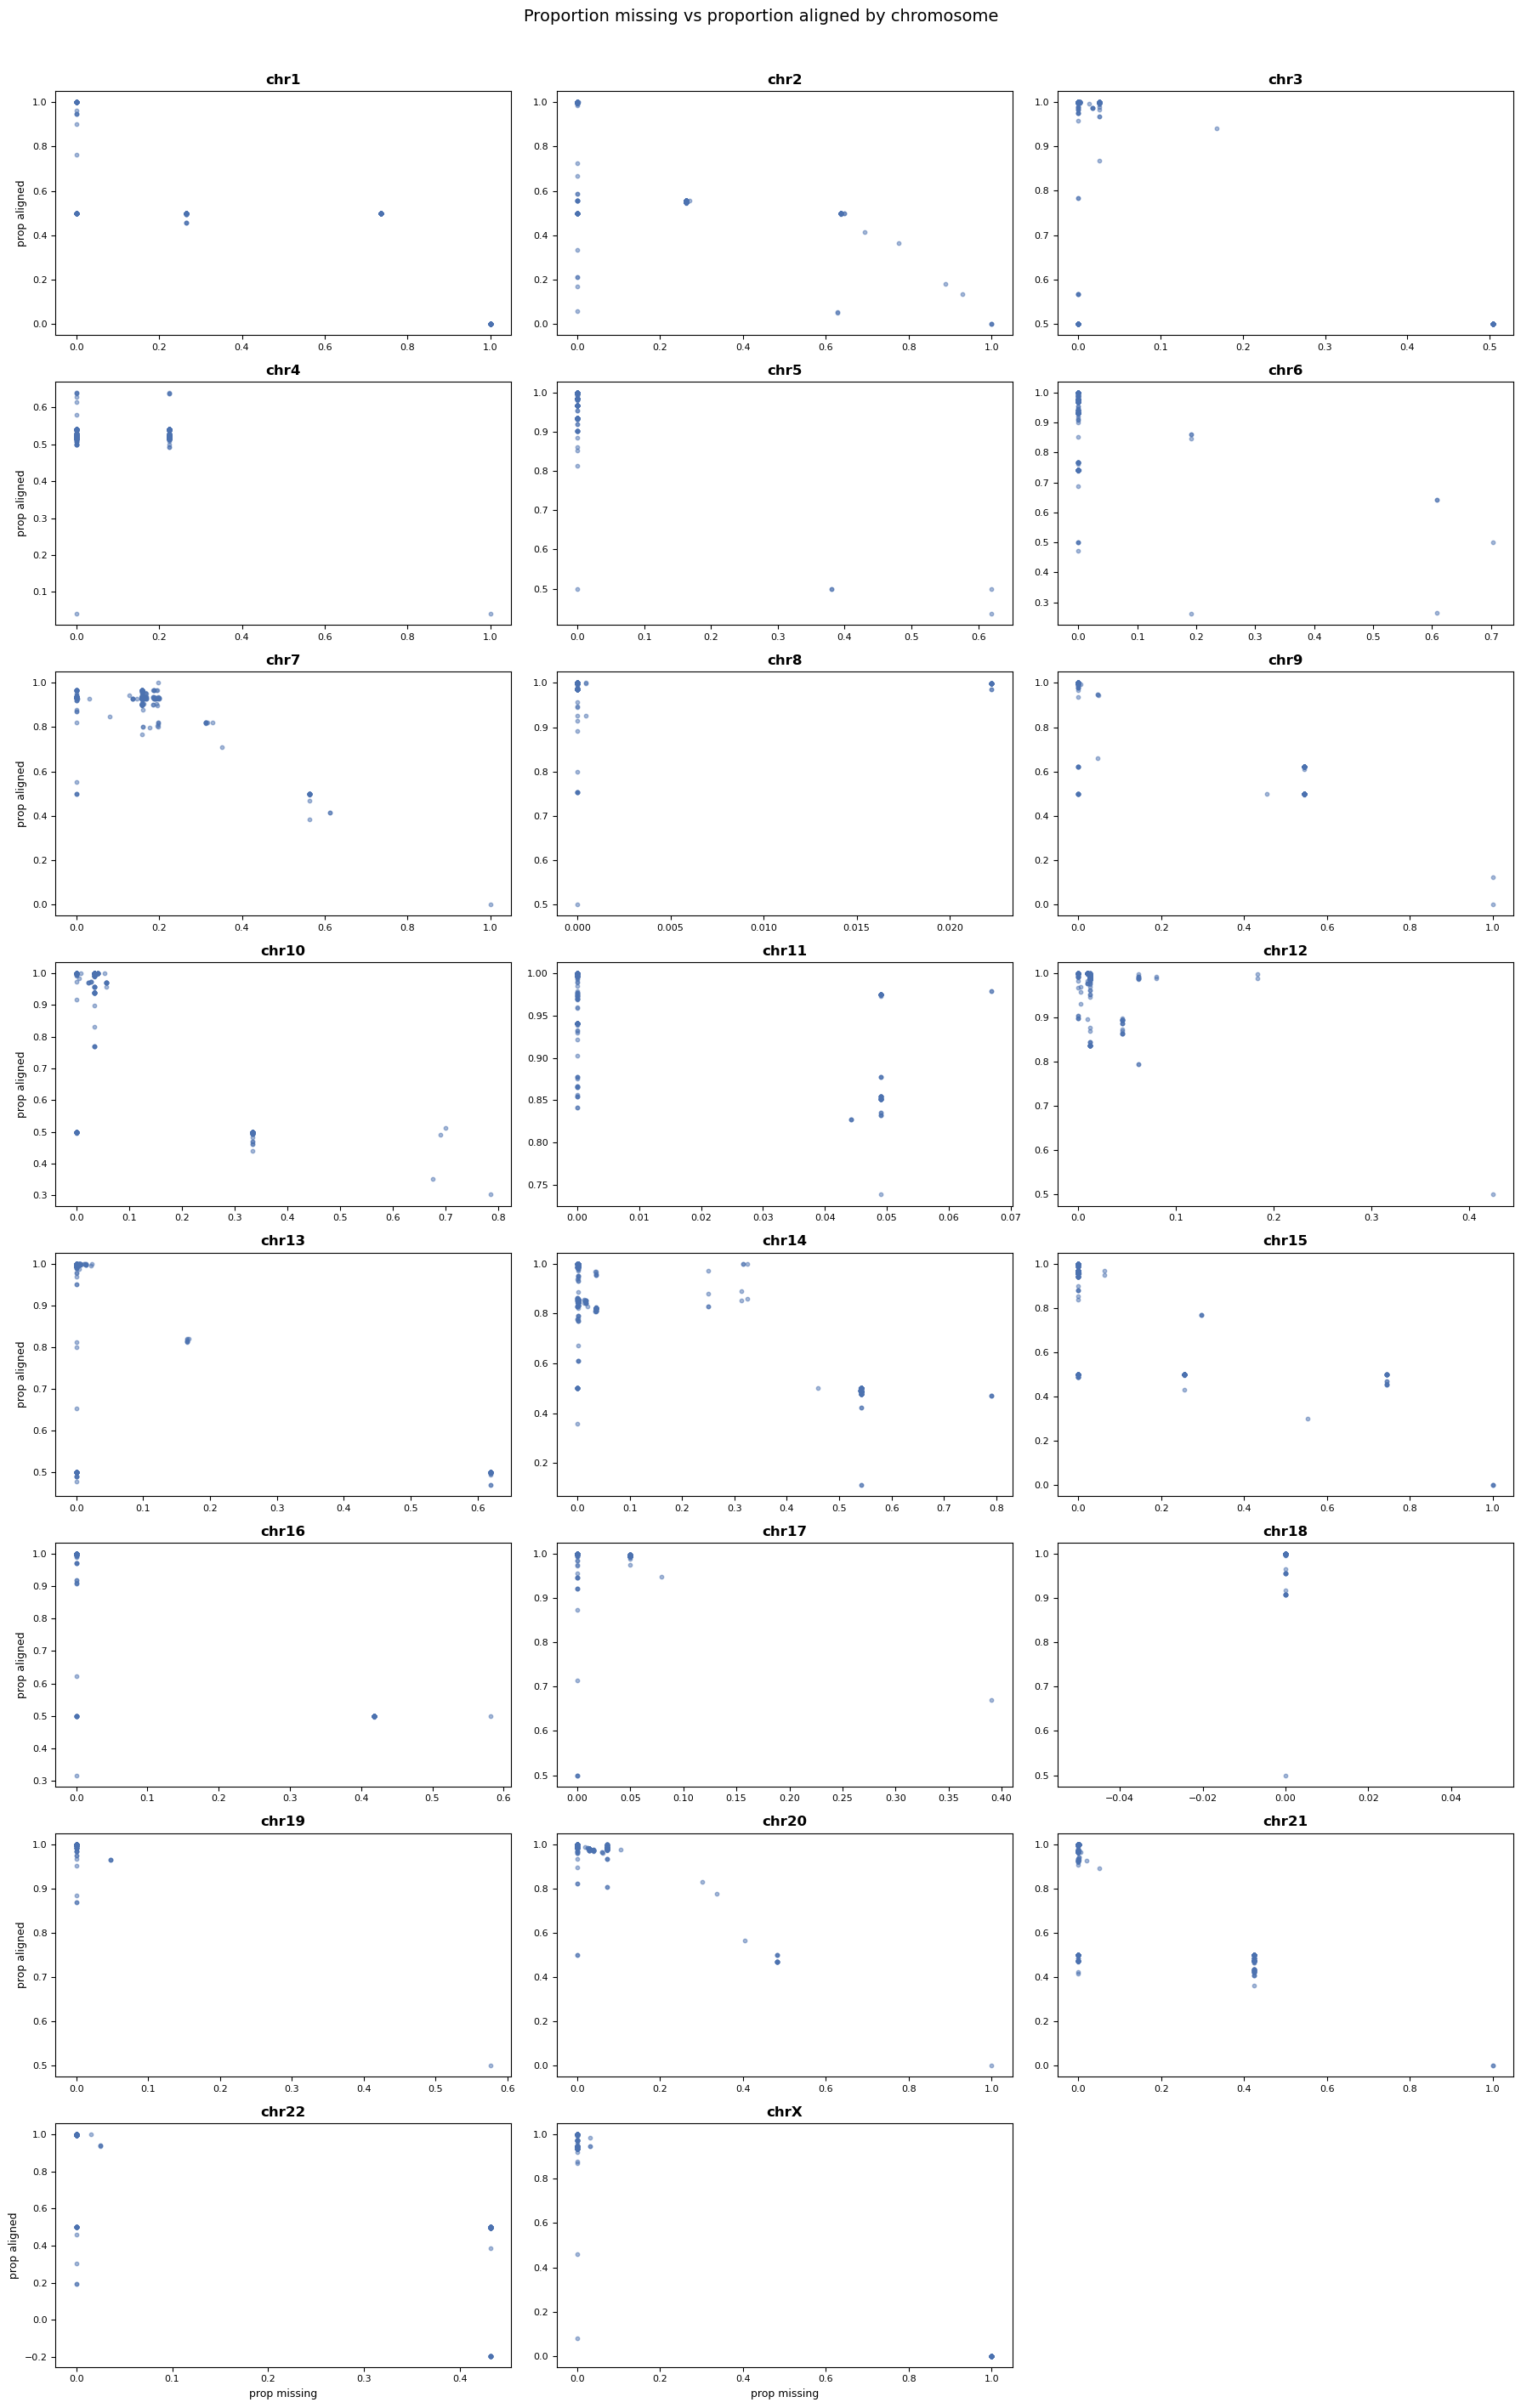

In [61]:
plot_chroms = [f"chr{i}" for i in range(1, 23)] + ["chrX"]

ncols = 3
nrows = int(np.ceil(len(plot_chroms) / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 3.5))
axes = axes.flatten()

for i, chrom in enumerate(plot_chroms):
    ax = axes[i]
    data = df[df["chrom"] == chrom].dropna(subset=["prop_missing", "prop_aligned"])
    ax.scatter(data["prop_missing"], data["prop_aligned"], alpha=0.5, s=10, color="#4C72B0")
    ax.set_title(chrom, fontsize=12, fontweight="bold")
    ax.set_xlabel("prop missing" if i >= (nrows - 1) * ncols else "", fontsize=9)
    ax.set_ylabel("prop aligned" if i % ncols == 0 else "", fontsize=9)
    ax.tick_params(labelsize=8)

for j in range(len(plot_chroms), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Proportion missing vs proportion aligned by chromosome", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


In [ ]:
### Filter samples with less than 20% aligned CHM13 bases

In [27]:
import pandas as pd
from pathlib import Path

chromosomes = [f"chr{i}" for i in range(1, 23)] + ["chrX", "chrY"]

output_dir = Path("/private/groups/patenlab/mira/centrolign/analysis/per_cigar_mutation_rates")

dfs = []
for chrom in chromosomes:
    fp = output_dir / f"output_{chrom}.tsv"
    if fp.exists():
        dfs.append(pd.read_csv(fp, sep="\t"))

centrolign_df = pd.concat(dfs, ignore_index=True)
centrolign_df

,sample1,sample2,chr,avg_array_len,aligned_bases,n_snvs,n_snvs_per_aligned_base,n_snvs_per_aligned_base_per_avg_len,n_short_indels,n_short_indels_per_aligned_base,n_short_indels_per_aligned_base_per_avg_len,n_svs,n_svs_per_avg_len
0,HG02040.1,NA18983.1,chr1,4054652.5,3245747,1649,0.000508,1.253004e-10,110,0.000034,8.358424e-12,290,0.000072
1,HG00099.2,HG04204.1,chr1,3743784.0,3062338,1944,0.000635,1.695635e-10,141,0.000046,1.229859e-11,294,0.000079
2,HG002.2,HG01252.1,chr1,3893989.5,3463767,1864,0.000538,1.381982e-10,177,0.000051,1.312290e-11,244,0.000063
3,HG01099.1,NA20805.1,chr1,6613613.0,6199955,1266,0.000204,3.087496e-11,50,0.000008,1.219390e-12,236,0.000036
4,HG03041.1,HG03516.1,chr1,3535938.5,2891810,828,0.000286,8.097592e-11,44,0.000015,4.303068e-12,140,0.000040
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4756,HG002.1,HG01261.1,chrY,308747.0,246302,327,0.001328,4.300085e-09,46,0.000187,6.049050e-10,15,0.000049
4757,HG00621.1,NA18945.1,chrY,304226.0,263387,31,0.000118,3.868753e-10,2,0.000008,2.495970e-11,4,0.000013
4758,CHM13.0,HG002.1,chrY,317335.5,317335,0,0.000000,0.000000e+00,1,0.000003,9.930323e-12,0,0.000000
4759,NA18952.1,NA19043.1,chrY,141483.5,106828,87,0.000814,5.756100e-09,6,0.000056,3.969724e-10,7,0.000049


/data/tmp/ipykernel_3405510/2792021803.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/data/tmp/ipykernel_3405510/2792021803.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/data/tmp/ipykernel_3405510/2792021803.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/data/tmp/ipykernel_3405510/2792021803.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/data/tmp/ip

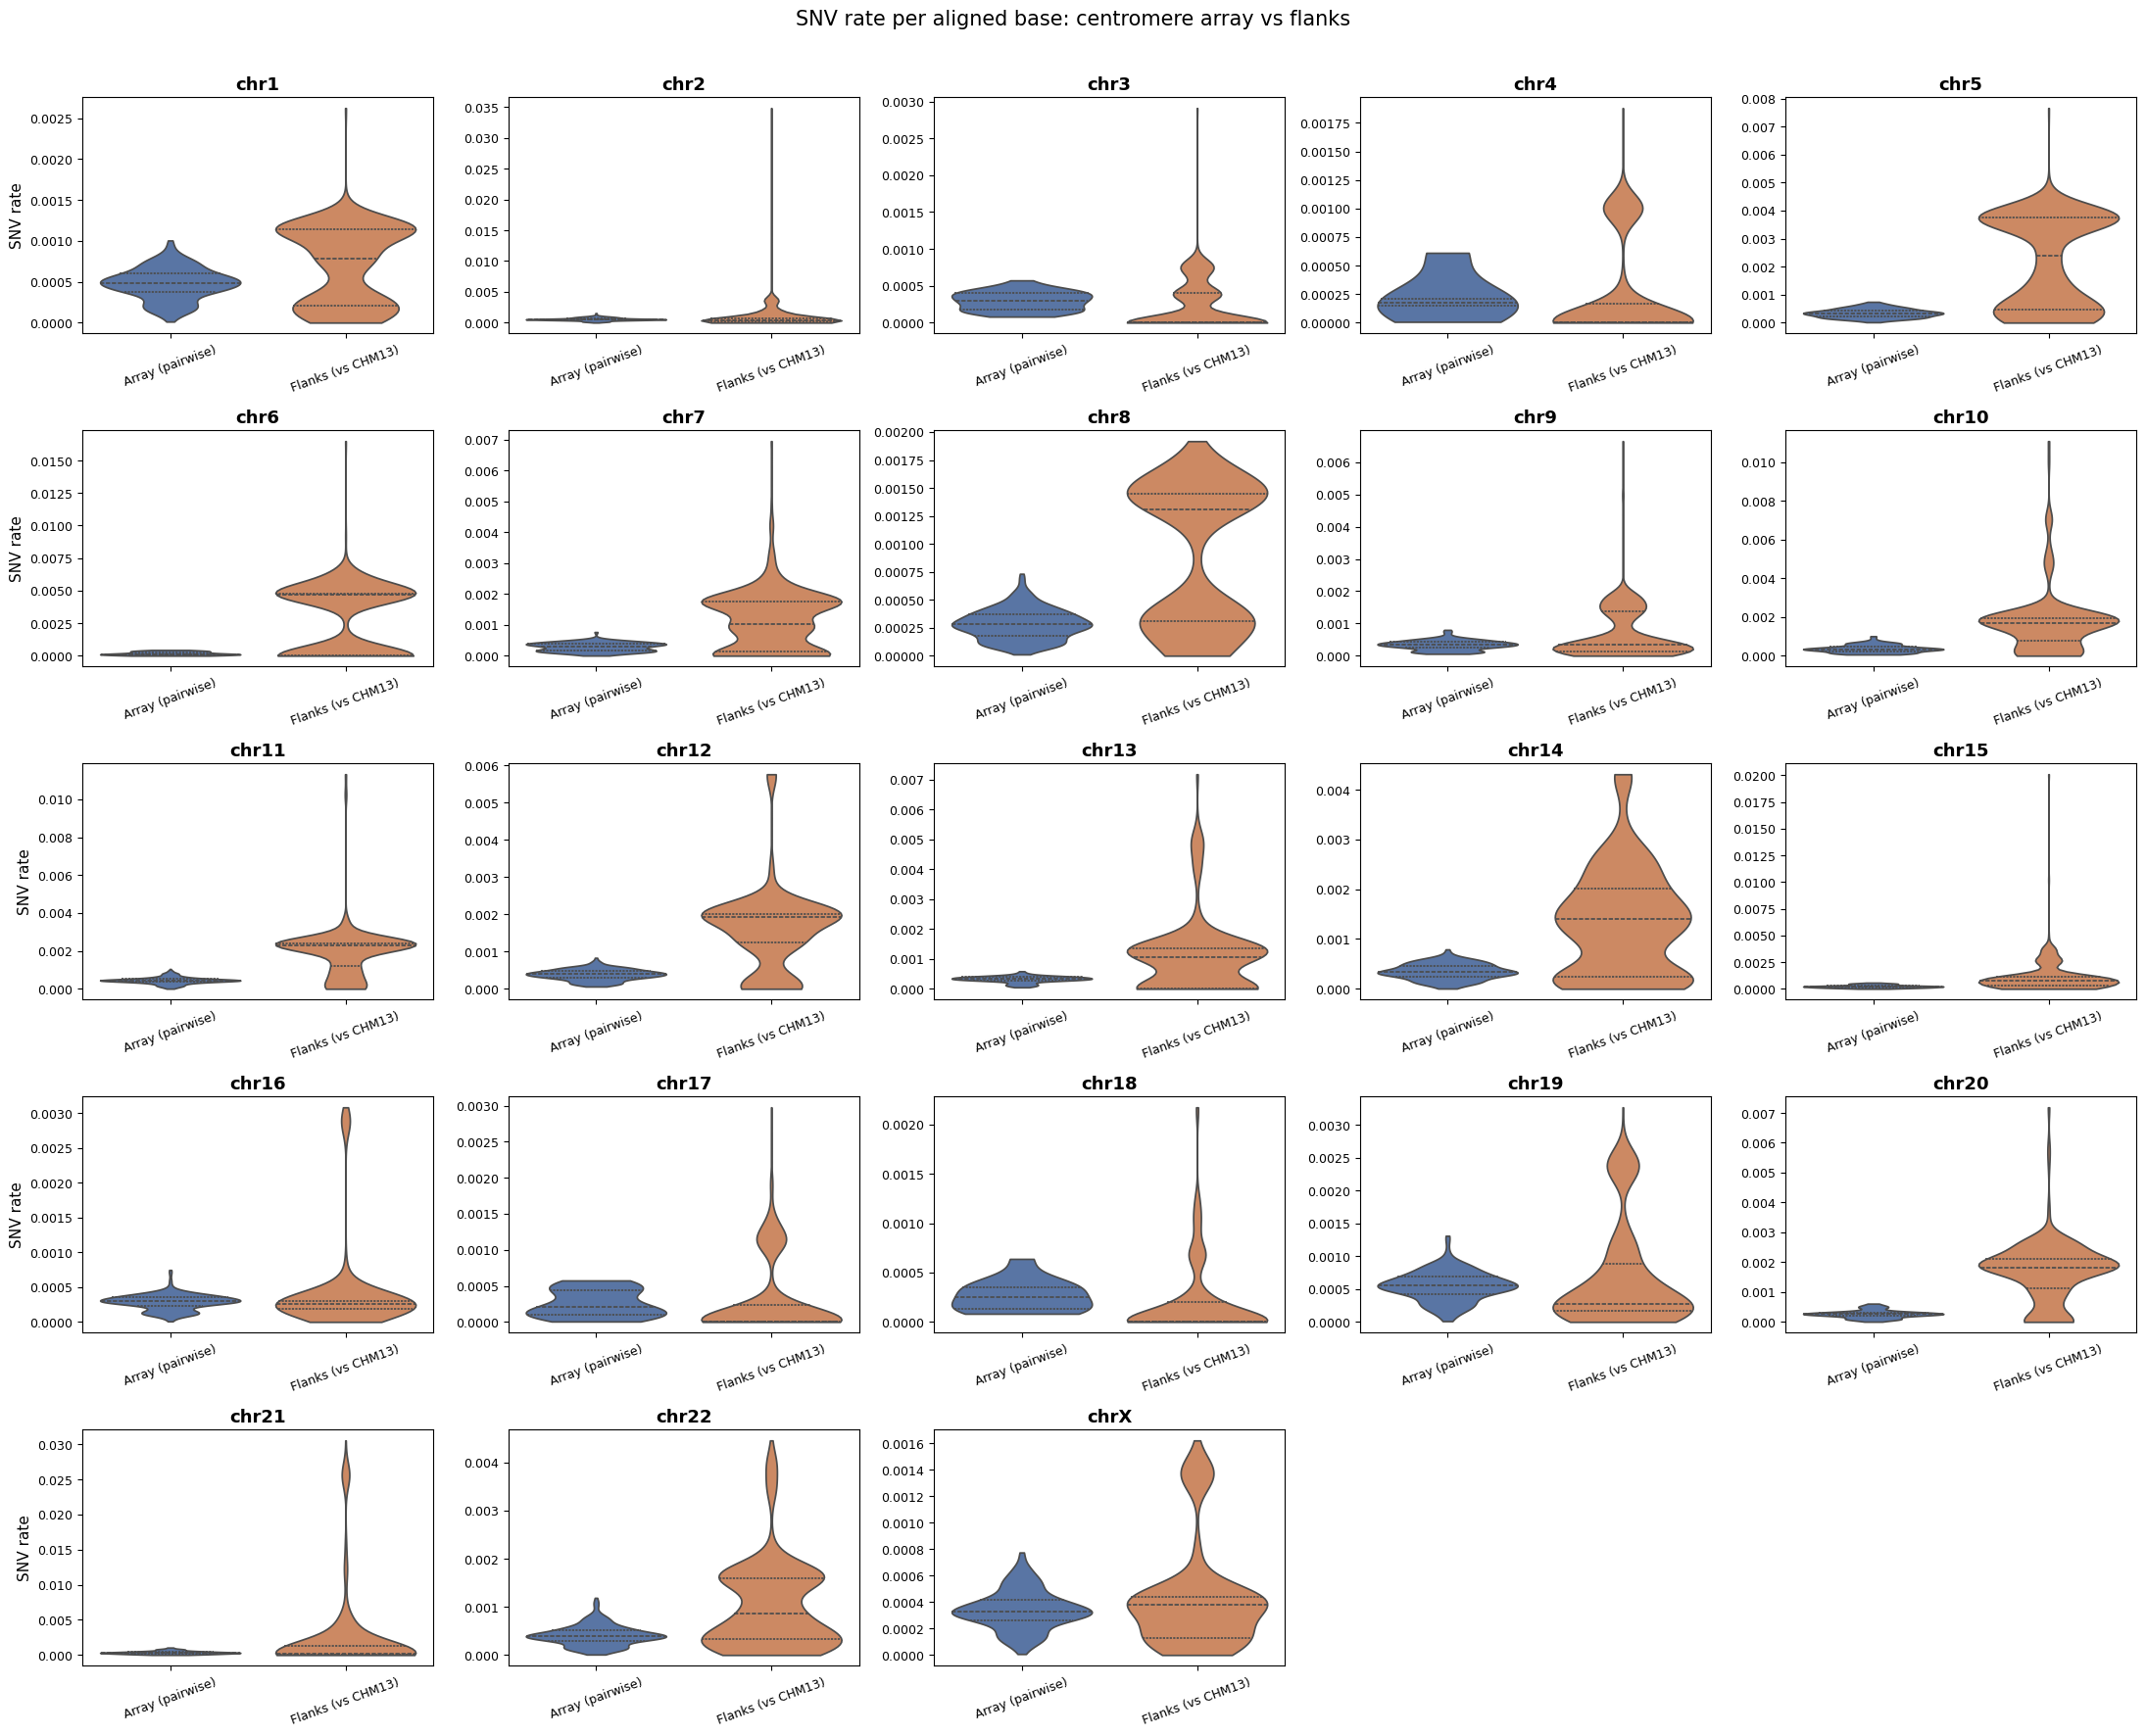

In [29]:
# ── SNV rate: array (pairwise) vs flanks (vs CHM13) ──────────────────────────

plot_chroms = [f"chr{i}" for i in range(1, 23)] + ["chrX"]

# Array data
array_plot = (
    centrolign_df[centrolign_df["chr"].isin(plot_chroms)]
    [["chr", "n_snvs_per_aligned_base"]]
    .rename(columns={"chr": "chrom", "n_snvs_per_aligned_base": "snv_rate"})
    .assign(source="Array (pairwise)")
)

# Flank data — drop rows with no aligned bases
flank_plot = (
    df[(df["chrom"].isin(plot_chroms)) & (df["aligned_bases"] > 0) & df["snv_rate"].notna()]
    [["chrom", "snv_rate"]]
    .assign(source="Flanks (vs CHM13)")
)

combined = pd.concat([array_plot, flank_plot], ignore_index=True)

# Layout
ncols = 5
nrows = int(np.ceil(len(plot_chroms) / ncols))
palette = {"Array (pairwise)": "#4C72B0", "Flanks (vs CHM13)": "#DD8452"}

fig, axes = plt.subplots(nrows, ncols, figsize=(22, nrows * 3.5))
axes = axes.flatten()

for i, chrom in enumerate(plot_chroms):
    ax = axes[i]
    data = combined[combined["chrom"] == chrom]
    sns.violinplot(
        data=data, x="source", y="snv_rate",
        palette=palette, ax=ax, inner="quartile", cut=0
    )
    ax.set_title(chrom, fontsize=13, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("SNV rate" if i % ncols == 0 else "", fontsize=11)
    ax.tick_params(axis="x", labelsize=9, rotation=20)
    ax.tick_params(axis="y", labelsize=9)

# Hide unused subplots
for j in range(len(plot_chroms), len(axes)):
    axes[j].set_visible(False)

fig.suptitle("SNV rate per aligned base: centromere array vs flanks", fontsize=15, y=1.01)
plt.tight_layout()
plt.show()